<a href="https://colab.research.google.com/github/pande17827/FastApi/blob/main/7.PUT%20and%20DELETE%20methods/1.PUT/1.introudction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("HEllo")

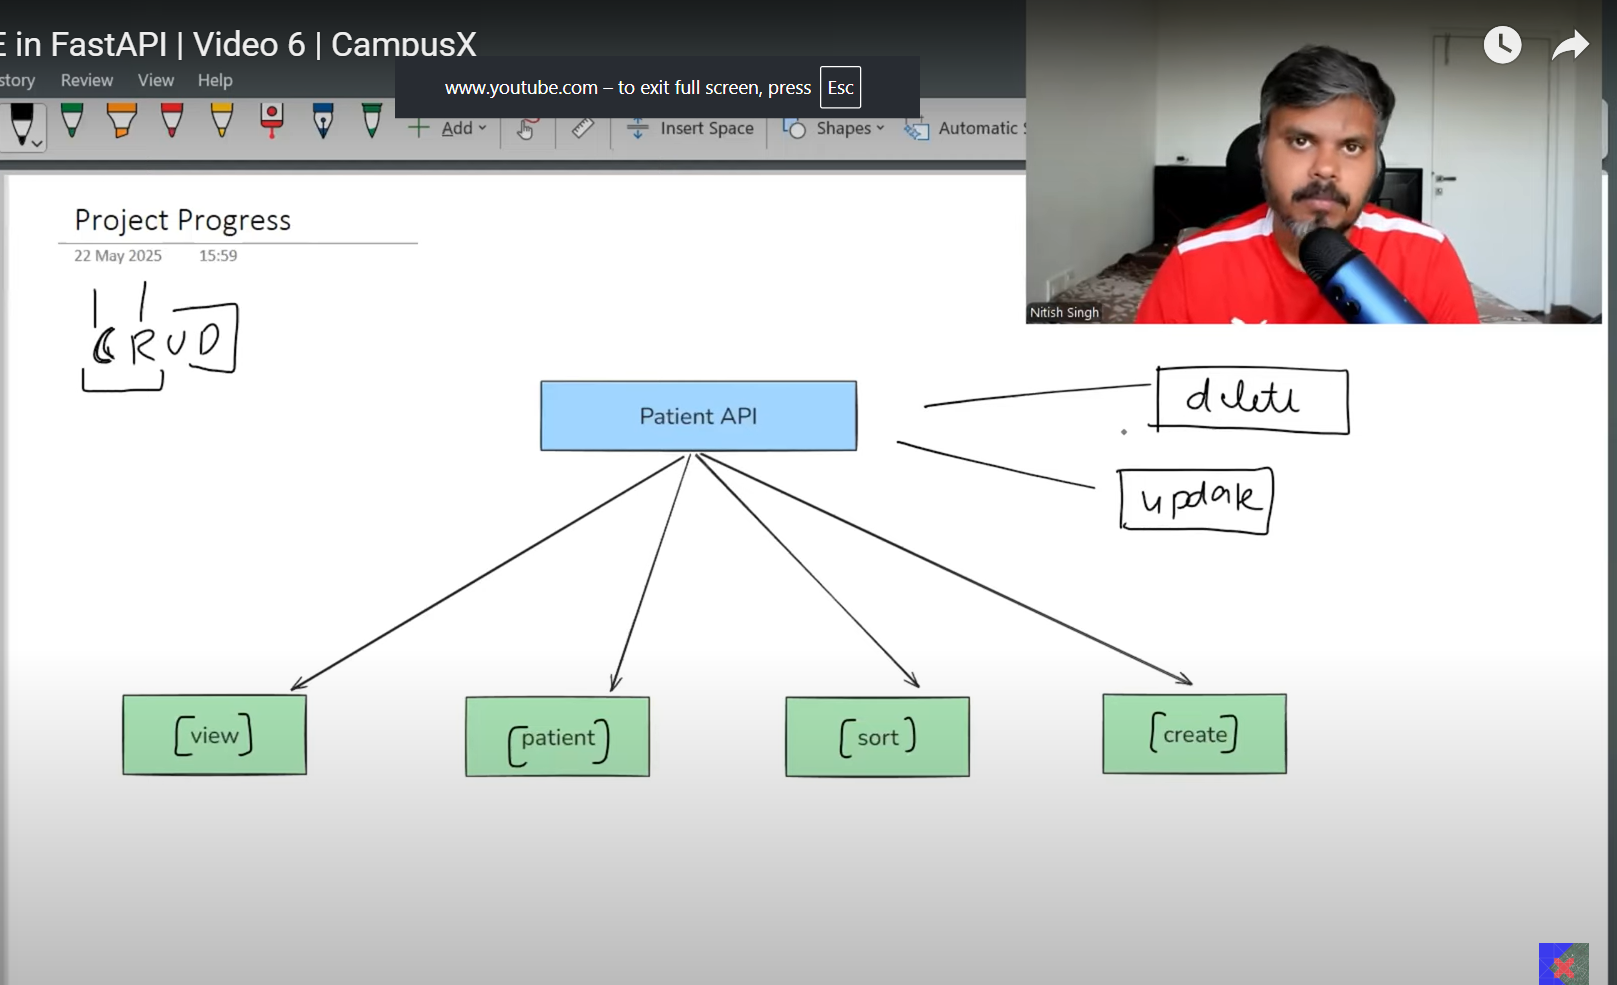

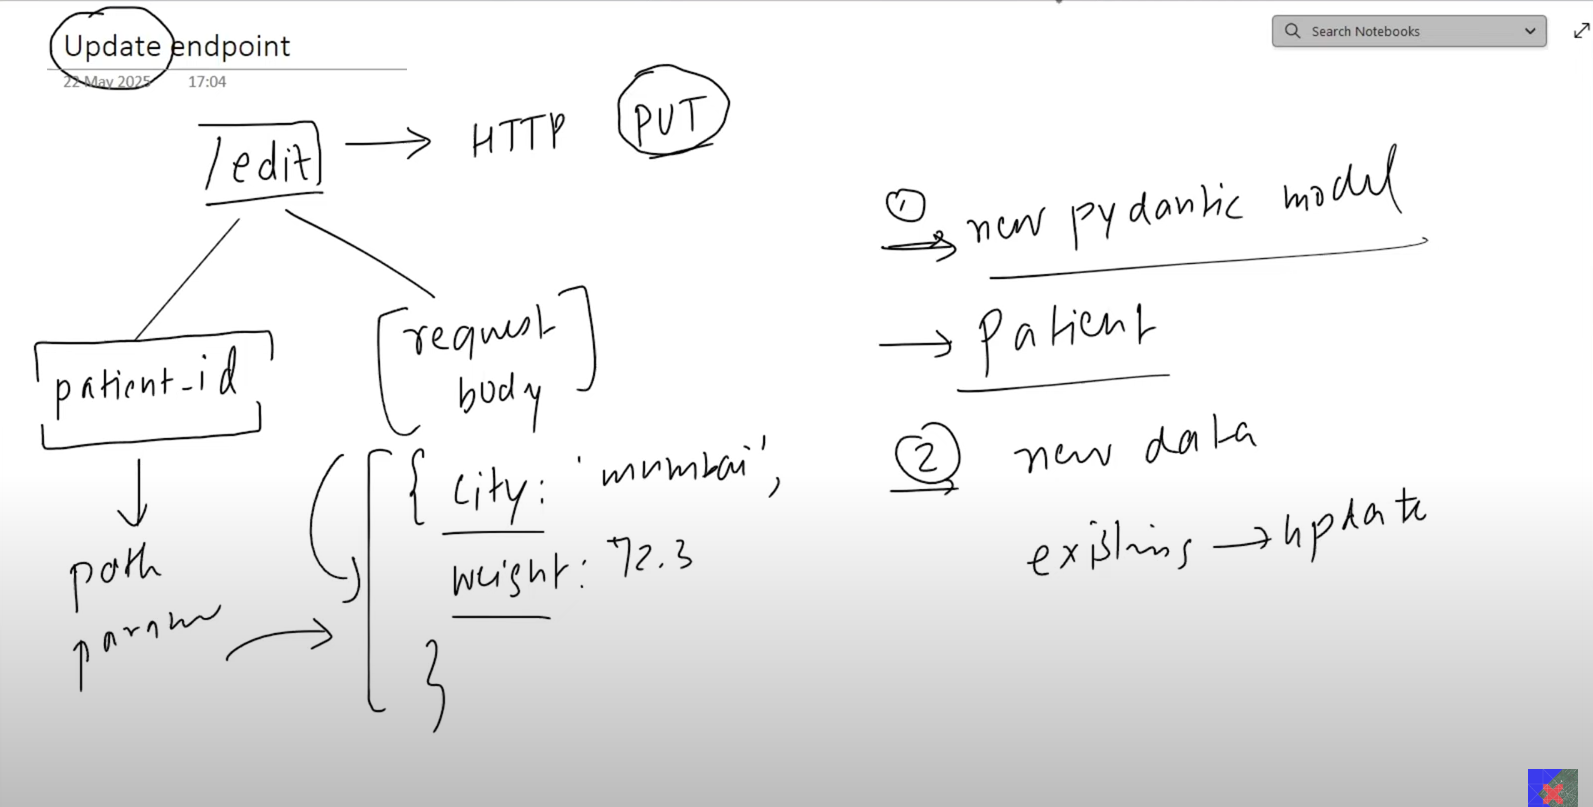

# Code


In [1]:
!pip install fastapi uvicorn pydantic nest-asyncio pyngrok

In [2]:
from time import daylight
from fastapi import FastAPI,Path,HTTPException,Query
from fastapi.responses import JSONResponse

import nest_asyncio
from pyngrok import ngrok
import uvicorn
import json
from google.colab import userdata

from pydantic import BaseModel,Field,computed_field
from typing import Annotated,Literal,Optional



# setting ngrok
ngrok_auth_token = userdata.get('NGROK_AUTHTOKEN')
ngrok.set_auth_token(ngrok_auth_token)


# running instance of the fast api
app = FastAPI()


# creating pydantic object
class Patient(BaseModel):
  id:Annotated[str,Field(...,description='ID of the patient',example='P001')]
  name:Annotated[str,Field(... , description="Name of the patient")]
  age:Annotated[int,Field(... , gt=0,lt=120,description="Age of the patient")]
  city:Annotated[str,Field(... , description="City where the patient is living")]
  gender:Annotated[Literal['male','female','other'],Field(description="gender of the Patient")]
  height:Annotated[float,Field(... , gt=0,description="Height of the patient in meter")]
  weight:Annotated[float,Field(... , gt=0,description="Weight of the patient in kg")]


  @computed_field
  @property
  def bmi(self)->float:
    bmi=round(self.weight/(self.height**2))
    return bmi

  @computed_field
  @property
  def verdict(self)->str:
    if self.bmi <18.5:
      return "Underweight"
    elif 18.5<=self.bmi<25:
      return "Normal"
    elif 25<=self.bmi<30:
      return "Overweight"


class PatientUpdate(BaseModel):
  name:Annotated[Optional[str],Field(default=None)]
  city:Annotated[Optional[str],Field(default=None)]
  age:Annotated[Optional[str],Field(default=None,gt=0)]
  gender:Annotated[Optional[Literal['male','female']],Field(default=None,gt=0)]
  gender:Annotated[Optional[float],Field(default=None,gt=0)]
  gender:Annotated[Optional[float],Field(default=None,gt=0)]


# function to load the datta from patients.json
def load_data():
  with open('/content/patients.json') as f:
    data = json.load(f)
  return data

# function to save data
def save_data(data):
  with open('/content/patients.json','w') as f:
    json.dump(data,f)



# first router for first endpoint
@app.get("/")
def Hello():
  return {"Message":"Patient Management System Api"}

@app.get('/about')
def about():
  return {"message":"A fully functional API tomanage your patients records"}

@app.get('/view') # this will display all the details of the patients
def view():
  data=load_data()
  return data

@app.get('/patient/{patient_id}')
def view_patient(patient_id:str=Path(...,description="ID of the patients in the Database",example="P001,P002,,,,,")):
  #loading all the patiennts
  data=load_data()

  if patient_id in data:
    return data[patient_id]
  raise HTTPException(status_code=404,detail="patient not found")

@app.get('/sor')
def sort_pateints(sort_by:str =Query(...,description="sort on the basis of height ,weights or bmi"),order:str=Query('asc',description="sort in asc or desc order")):
  valid_filed=["height","weight","bmi"]

  if sort_by not in valid_filed:
    raise HTTPException(status_code=400,detail="Invalid field select from height,weight,bmi")

  if order not in ['asc','desc']:
    raise HTTPException(status_code=400,detail="invalid order select between asc and desc")

  data=load_data()

  sort_order=True if order=="desc" else False

  sorted_data=sorted(data.values(),key=lambda x:x.get(sort_by,0),reverse=sort_order)

  return sorted_data



@app.post('/create')
def create_patient(patient:Patient):

  #step1:-loading existing data
  data=load_data()


  #step2:-checkif the patient already exist
  if patient.id in data:
    raise HTTPException(status_code=400,detail="patient already exist")

  #step3:-new patient add to the database
  """NOTE: patient is Pydantic Object where as data is a dictionary both are not same datatype
            therefore we need conversion of Pydantic object to dictionary and viceversa"""

  """patient is an instance of your Pydantic model Patient.
    patient.id accesses the patient's ID value. For example, "P006"

    ✅ So what does data[patient.id] = {...} do?
    It adds a new entry to the data dictionary using the patient's ID as the key.

    Let’s say patient.id == "P006" — this line will do:

    python
    Copy code
    data["P006"] = {
        "name": "Rahul Jain",
        "age": 31,
        ...
    }
    If the ID "P006" already exists, this will overwrite the existing entry.

    If it doesn't exist, it will create a new entry.


    """

  data[patient.id]=patient.model_dump(exclude='id')

  """data[patient.id] = patient.model_dump(exclude='id')
    Let’s break it down clearly:

    ✅ What it does:
    It adds a new patient entry to the data dictionary, using the patient's ID as the key, and a dictionary of their other details as the value.

    🔍 Breakdown:
    patient.id
    This gets the patient’s ID, like "P006".

    patient.model_dump(exclude='id')
    model_dump() is a method from Pydantic.

    It converts the Patient Pydantic model to a Python dictionary.

    The exclude='id' part tells it not to include the "id" field in the output.

  """

  #step4:-saving info into json file
  save_data(data)

  #step5:-tell the clien that everthing is successful by returing the response
  return JSONResponse(status_code=200,content={'message':'patient created successfully'})


@app.put('/edit/{patient_id}')
def update_patient(patient_id:str,patient_update_data:PatientUpdate):
  data=load_data()
  # checking if patient is already present
  if patient_id not in data:
    raise HTTPException(status_code=404,detail="patient not found")

  existing_patient_info=data[patient_id]

  # converting pydantic object into dictionary
  updated_patient_info=patient_update_data.model_dump(exclude_unset=True)

  for key,values in updated_patient_info.items():
    existing_patient_info[key]=values

  existing_patient_info['id']=patient_id
  patient_pydantic_obj=Patient(**existing_patient_info)

  # pydantic object -> dictionary
  existing_patient_info=patient_pydantic_obj.model_dump(exclude='id')

  # add this dictionary to data
  data[patient_id]=existing_patient_info

  # saving data
  save_data(data)

  return JSONResponse(status_code=200,content={'message':'patient updated successfully'})






# Apply nest_asyncio to allow running uvicorn inside notebook
nest_asyncio.apply()

# Open an ngrok tunnel to the default uvicorn port 8000
public_url = ngrok.connect(8000)
print(f"Public URL: {public_url}")

# Run the FastAPI app
uvicorn.run(app, host="0.0.0.0", port=8000)

<ipython-input-2-3231700671>:90: DeprecationWarning: `example` has been deprecated, please use `examples` instead
  def view_patient(patient_id:str=Path(...,description="ID of the patients in the Database",example="P001,P002,,,,,")):
INFO:     Started server process [299]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public URL: NgrokTunnel: "https://2b4b-34-80-243-39.ngrok-free.app" -> "http://localhost:8000"
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "GET / HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "PUT /edit/P004 HTTP/1.1" 422 Unprocessable Entity
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "PUT /edit/P004 HTTP/1.1" 422 Unprocessable Entity
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "PUT /edit/P004 HTTP/1.1" 422 Unprocessable Entity
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "PUT /edit/P001 HTTP/1.1" 422 Unprocessable Entity
INFO:     2402:a00:405:d365:d199:6e49:be67:22f5:0 - "PUT /edit/P001 HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Finished server process [299]
